## 📋 Project: Credit Classification

In this project, we build a machine learning model to classify credit scores into categories.  
The objective is to identify whether a customer has a good or poor credit profile based on financial and behavioral features.

This project is divided into four main parts:
1. Data Preparation & Exploratory Data Analysis (EDA)
2. Logistic Regression
3. Imbalanced Data Techniques
4. Ensemble Models

## 📋 Step 1: Data Preparation & EDA

In this step, we prepare and explore the dataset to better understand the variables and their impact on the target.

- Import the dataset and perform necessary data type conversions  
- Modify the target variable by grouping "Standard" and "Good" into one category to create a binary classification problem  
- Perform exploratory data analysis (EDA) to identify important features  
- Analyze correlations between variables and remove irrelevant or redundant features  
- Handle missing values and outliers if necessary  
- Prepare the data for modeling by:
  - Creating dummy variables (encoding categorical features)
  - Splitting the data into training and testing sets
  - Scaling numerical features if needed

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Metrics
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Model selection
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

# Load dataset
credit_df = pd.read_csv("credit_train_clean.csv")

# Drop unnecessary columns
credit_df = credit_df.drop(["Name", "SSN", "ID", "Customer_ID"], axis=1)

# Display first rows
credit_df.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,1,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",...,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,2,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",...,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,3,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",...,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,4,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",...,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",...,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


In [2]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Month                     100000 non-null  int64  
 1   Age                       100000 non-null  float64
 2   Occupation                100000 non-null  object 
 3   Annual_Income             100000 non-null  float64
 4   Monthly_Inhand_Salary     100000 non-null  float64
 5   Num_Bank_Accounts         100000 non-null  float64
 6   Num_Credit_Card           100000 non-null  float64
 7   Interest_Rate             100000 non-null  float64
 8   Num_of_Loan               100000 non-null  float64
 9   Type_of_Loan              100000 non-null  object 
 10  Delay_from_due_date       100000 non-null  float64
 11  Num_of_Delayed_Payment    100000 non-null  float64
 12  Changed_Credit_Limit      100000 non-null  float64
 13  Num_Credit_Inquiries      100000 non-null  fl

<Axes: xlabel='Credit_Score', ylabel='Age'>

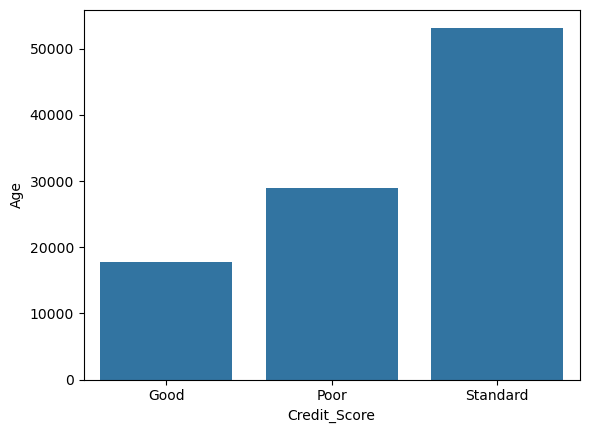

In [3]:
sns.barplot(data=credit_df.groupby("Credit_Score")["Age"].count().reset_index(), x="Credit_Score", y="Age")

In [4]:
credit_df["Credit_Score"] = credit_df["Credit_Score"].map({
    "Good": "Good or Standard",
    "Standard": "Good or Standard",
    "Poor": "Poor"
})

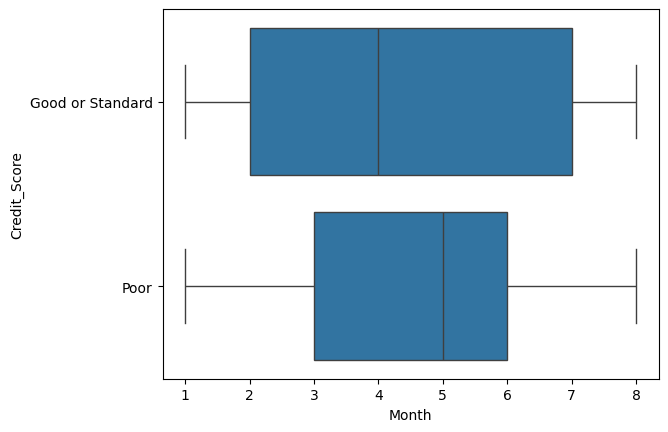

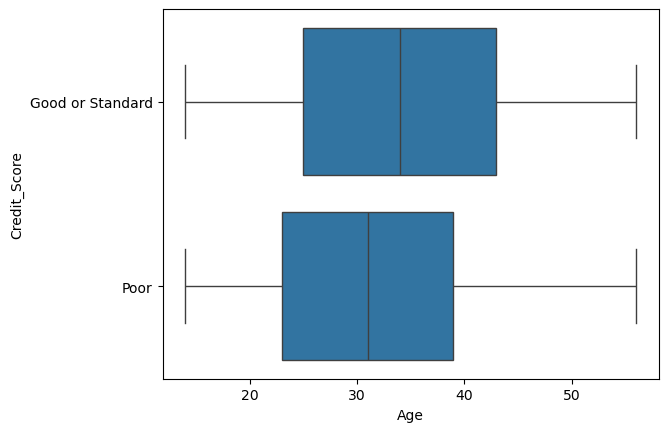

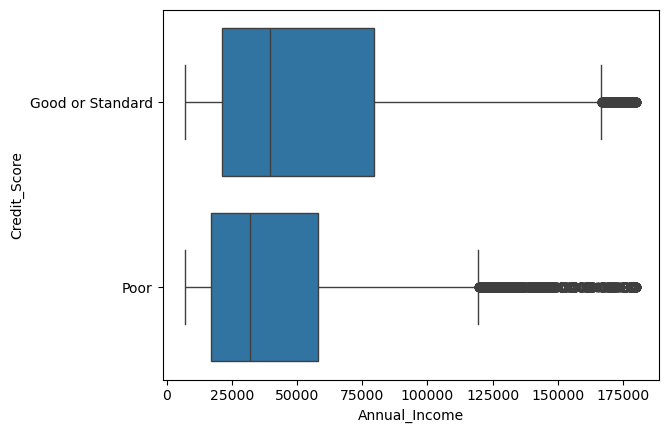

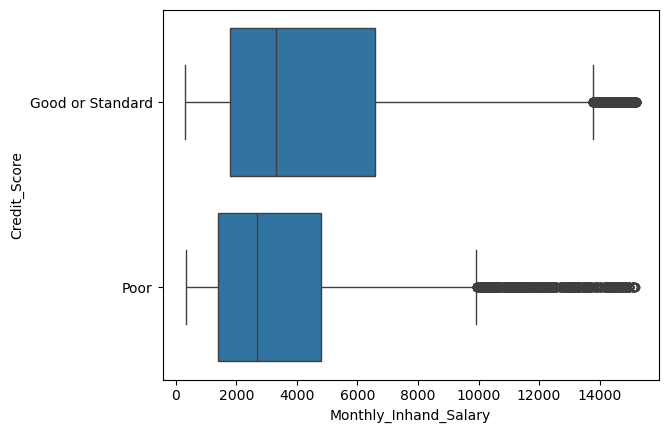

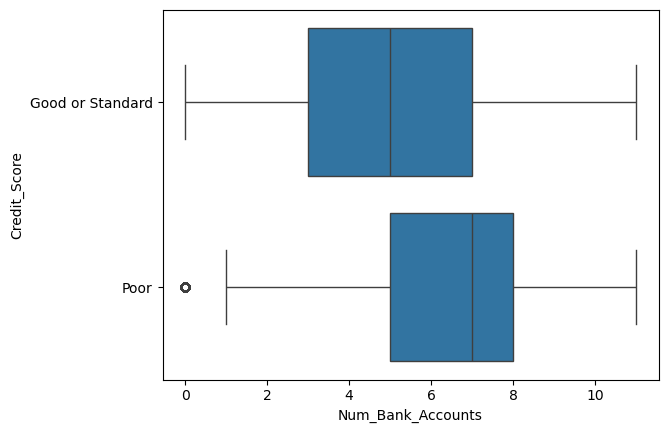

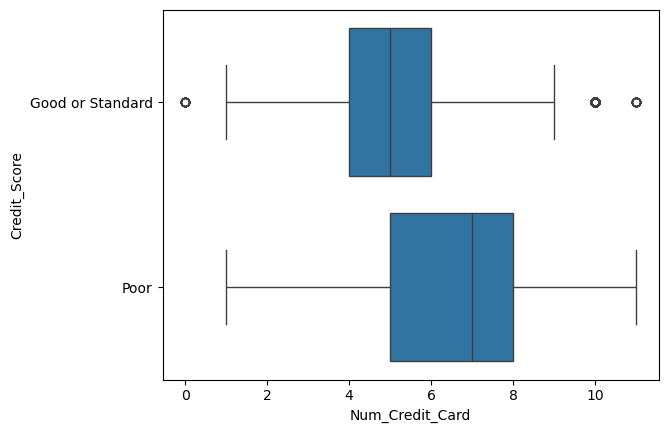

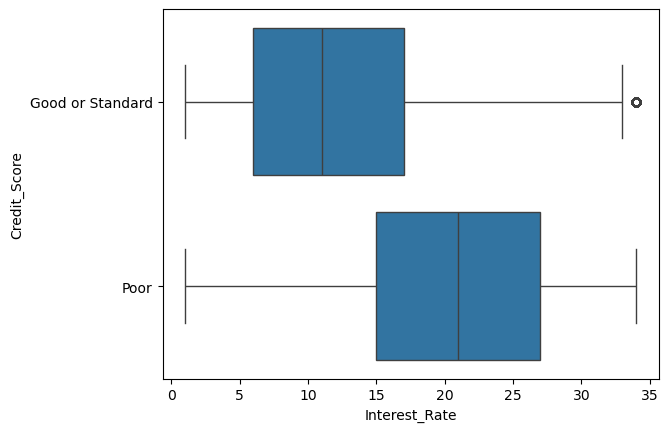

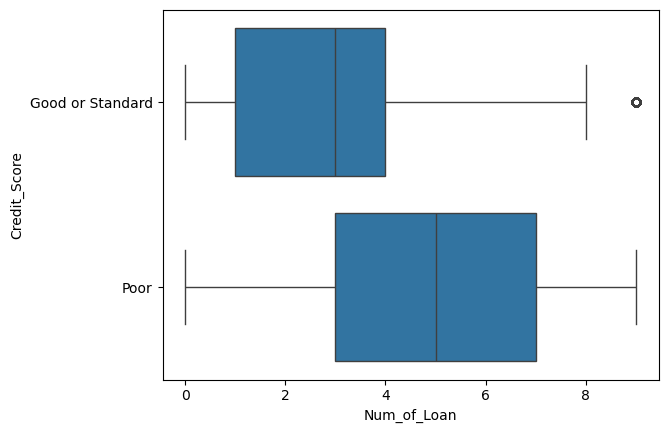

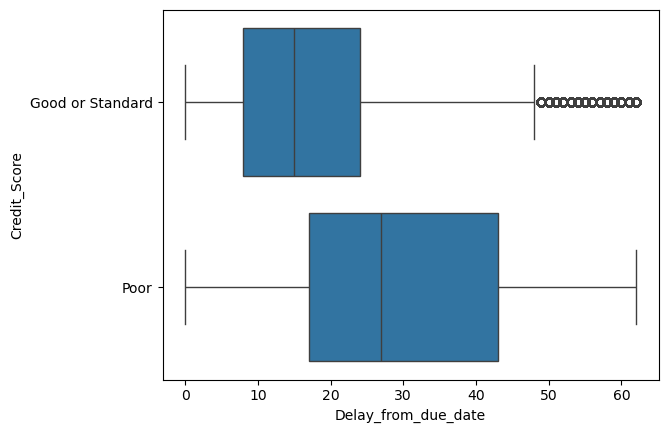

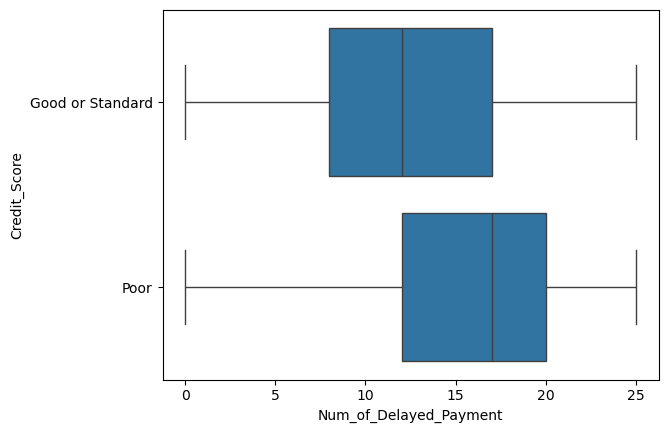

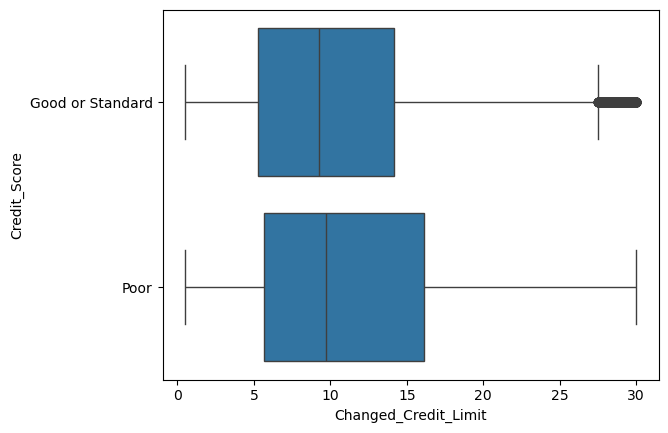

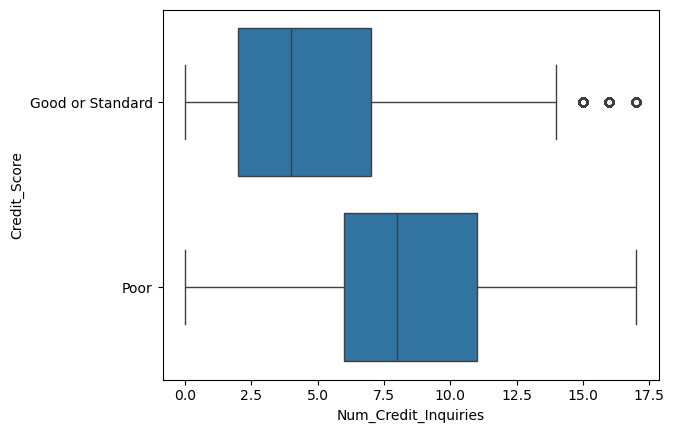

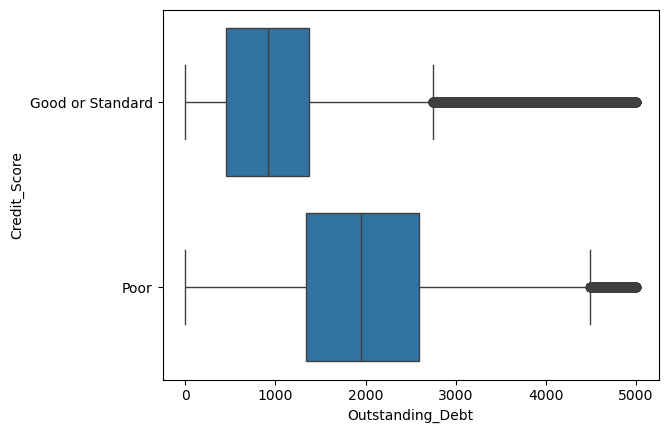

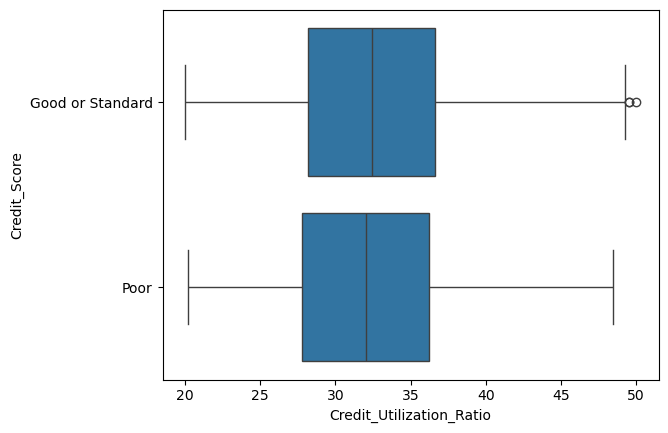

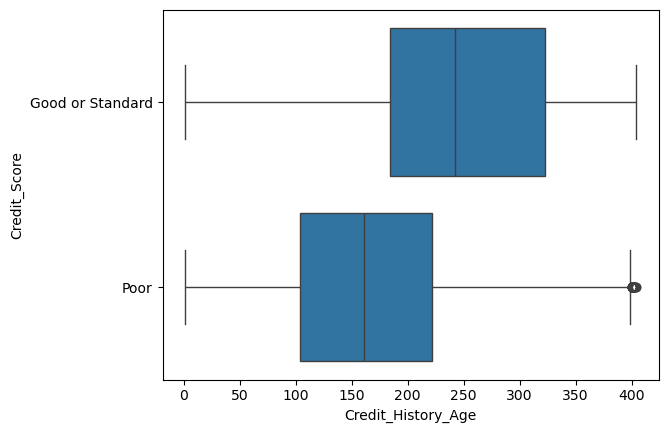

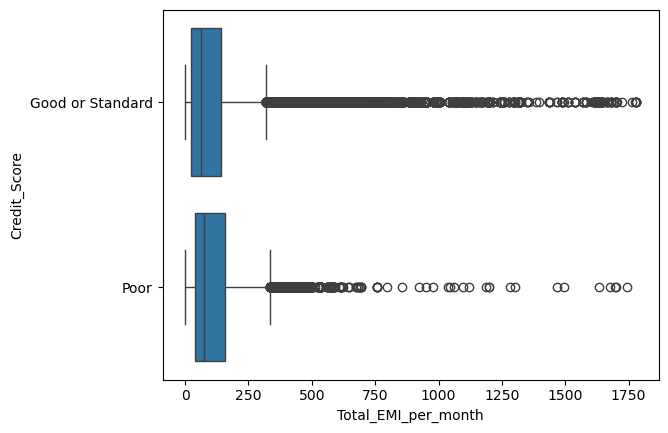

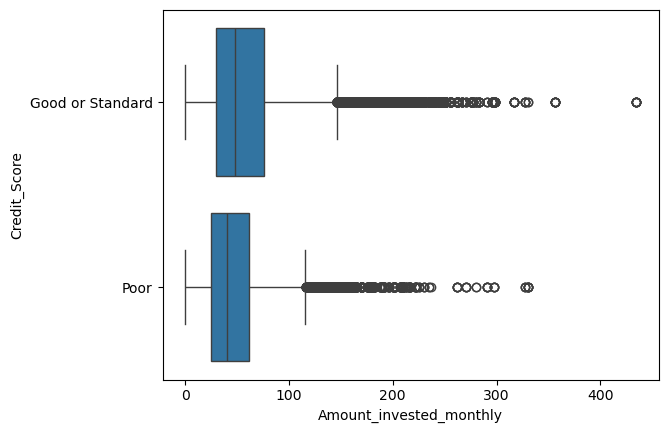

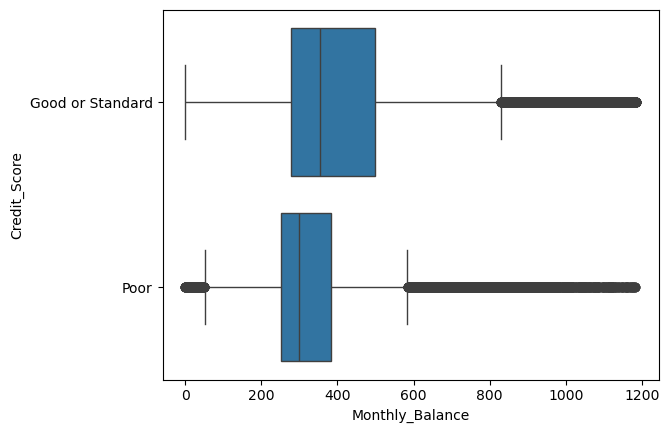

In [5]:
def num_plotter(data, target):
    for col in data.select_dtypes(["int", "float"]):
        sns.boxplot(data=data, x=col, y=target)  # stat="percent", kde=True, bins=20
        
        plt.show()

num_plotter(credit_df, "Credit_Score")

In [6]:
credit_df["target"] = credit_df["Credit_Score"].map({
    "Good or Standard": 0,
    "Poor": 1
})

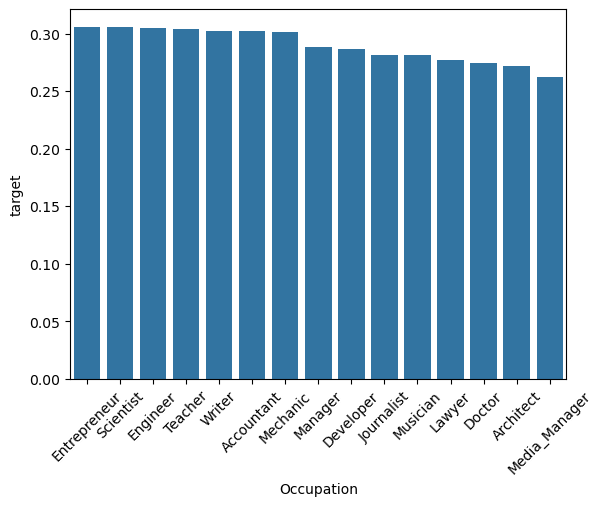

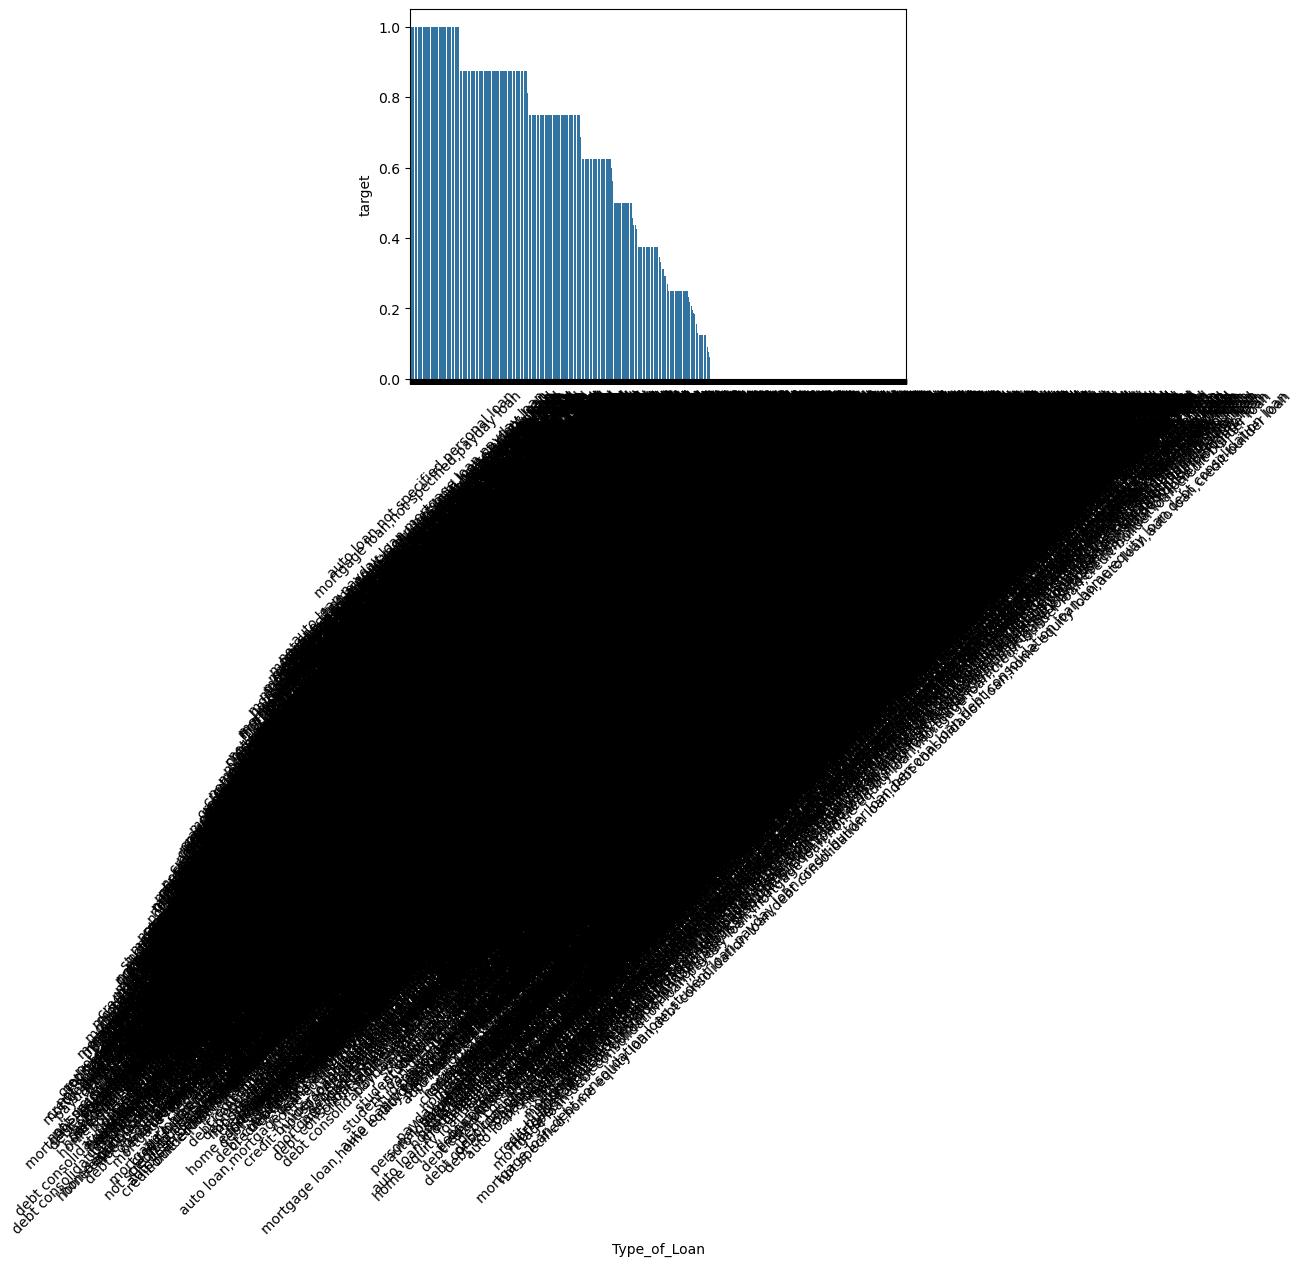

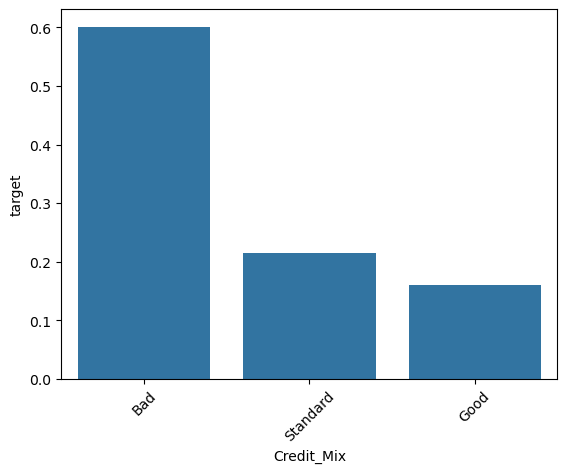

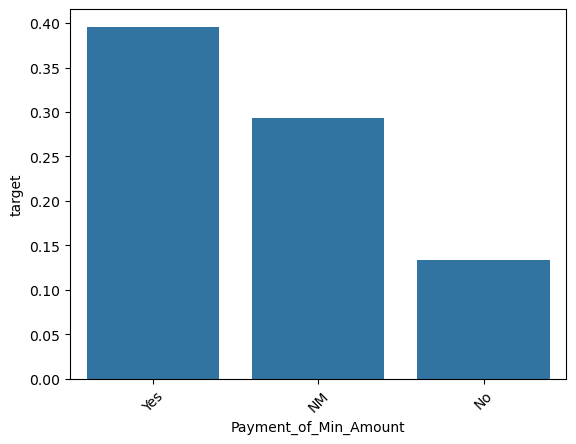

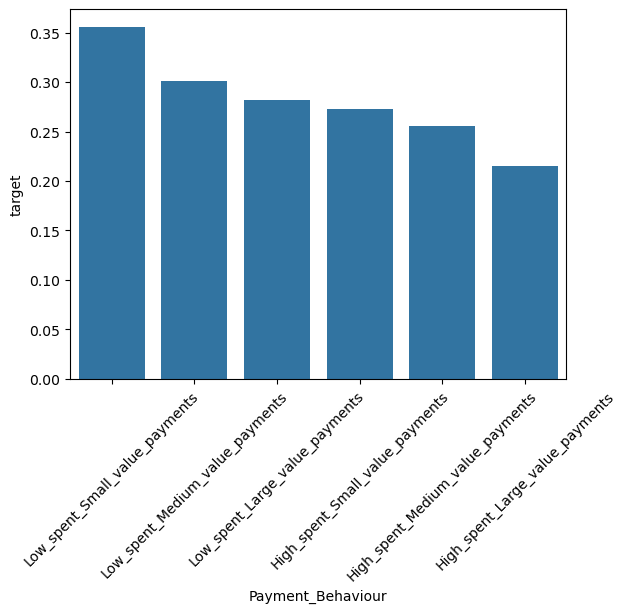

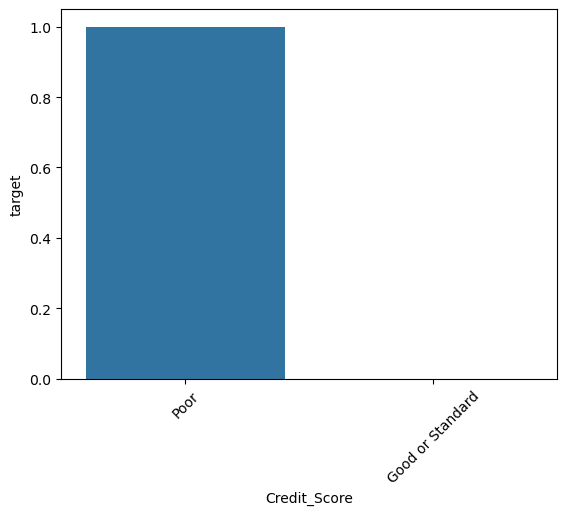

In [7]:
def cat_plotter(data, target):
    for col in data.select_dtypes(["object"]).columns:
        sns.barplot(
            data=(
                data
                .groupby(col, as_index=False)
                .agg({"target": "mean"})
                .sort_values(by="target", ascending=False)
            ),
            x=col,
            y=target
        )
        plt.xticks(rotation=45)
        plt.show()

cat_plotter(credit_df, "target")

In [8]:
# Credit Card X Credit Inquiries or Outstanding Debt/Payment Behaviour

features = [
    "Age",
    "Month",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Num_of_Loan",
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Credit_Utilization_Ratio",
    "Amount_invested_monthly",
    "Interest_Rate",
    "Num_Bank_Accounts",
    "Changed_Credit_Limit",
    "Num_Credit_Card",
    "Credit_History_Age",
    "Payment_of_Min_Amount",
    "Monthly_Balance",
    "Payment_Behaviour",
    "Num_Credit_Inquiries",
    "Outstanding_Debt",
    "Credit_Mix",
    "Total_EMI_per_month",
    #"Type_of_Loan",
]

X = pd.get_dummies(credit_df[features], dtype="int", drop_first=True)
y = credit_df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2023)

In [9]:
std = StandardScaler()

X_train_std = std.fit_transform(X_train)
X_test_std = std.transform(X_test)

## 📋 Step 2: Logistic Regression

In this step, we build a baseline classification model using Logistic Regression and evaluate its performance.

- Train a Logistic Regression model using default hyperparameters  
- Tune hyperparameters to improve model performance  
- Evaluate the model using:
  - Accuracy
  - Precision
  - Recall
  - F1-score  
- Adjust the classification threshold to maximize the F1-score  
- Plot the ROC curve and compute the AUC score to assess model performance

In [11]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=5000)

lr = logreg.fit(X_train, y_train)

print(f"Train Accuracy: {lr.score(X_train, y_train)}")
print(f"Test Accuracy: {lr.score(X_test, y_test)}")

Train Accuracy: 0.7867625
Test Accuracy: 0.786


C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
from sklearn.model_selection import GridSearchCV

parameters = {
    "C": np.linspace(.1, 1.1, 11),
    "penalty": ["l1", "l2"],
}

gridsearch = GridSearchCV(LogisticRegression(solver="saga", max_iter=1000), parameters)

gridsearch.fit(X_train_std, y_train)

gridsearch.best_params_

{'C': 0.30000000000000004, 'penalty': 'l2'}

In [13]:
logreg = LogisticRegression(max_iter=5000, **gridsearch.best_params_)

lr_tuned = logreg.fit(X_train_std, y_train)

print(f"Train Accuracy: {lr_tuned.score(X_train_std, y_train)}")
print(f"Test Accuracy: {lr_tuned.score(X_test_std, y_test)}")

Train Accuracy: 0.7892
Test Accuracy: 0.7877


<Axes: >

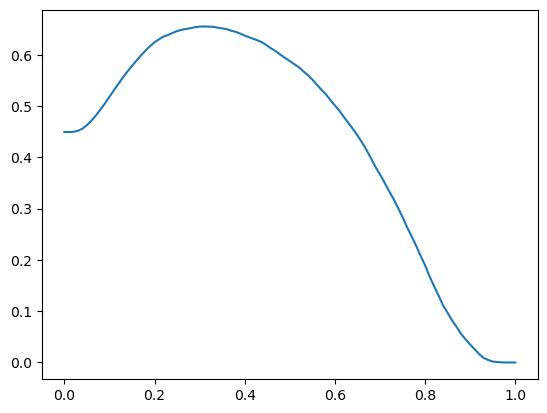

In [14]:
from sklearn.metrics import f1_score

f1 = []

thresholds = np.linspace(0, 1, 101)

for thresh in thresholds:
    y_pred = (lr_tuned.predict_proba(X_train_std)[:, 1] > thresh)
    f1.append(f1_score(y_train, y_pred))

sns.lineplot(x=thresholds, y=f1)

In [15]:
thresh = thresholds[f1.index(max(f1))]

thresh

0.31

## 📋 Step 3: Imbalanced Data Techniques

In this step, we address the issue of class imbalance to improve model performance.

- Apply SMOTE (Synthetic Minority Oversampling Technique) to balance the dataset  
- Retrain the model using the resampled data  
- Tune the classification threshold again  
- Evaluate performance using:
  - Accuracy
  - F1-score
  - AUC  
- Compare results before and after applying SMOTE to measure improvement

In [16]:
preds = lr_tuned.predict_proba(X_test_std)[:, 1] > thresh

print(f"Accuracy: {accuracy_score(y_test, preds)}")
print(f"Precision: {precision_score(y_test, preds)}")
print(f"Recall: {recall_score(y_test, preds)}")
print(f"F1: {f1_score(y_test, preds)}")

Accuracy: 0.7861
Precision: 0.6165630213863188
Recall: 0.6990541702493551
F1: 0.6552224371373307


In [17]:
confusion_matrix(y_test, preds)

array([[11657,  2528],
       [ 1750,  4065]], dtype=int64)

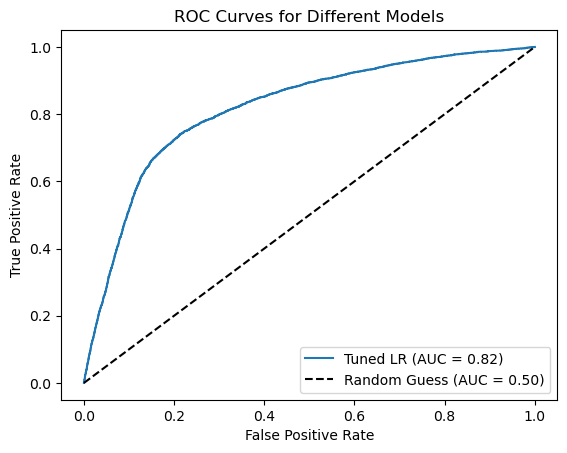

In [18]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Generate ROC AUC for tuned model
y_probs = lr_tuned.predict_proba(X_test_std)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = auc(fpr, tpr)

# Plot the ROC curve
plt.plot(fpr, tpr, label=f'Tuned LR (AUC = {auc_score:.2f})')

# Draw Random Guess
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')

# Modify Formatting
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Different Models')
plt.legend()
plt.show()

## 📋 Step 4: Ensemble Models

In this final step, we explore advanced models to further improve performance.

- Train ensemble models such as:
  - Random Forest
  - Gradient Boosting  
- Compare their performance with Logistic Regression  
- Evaluate using the same metrics:
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - AUC  
- Select the best-performing model for the final solution

In [19]:
import imblearn.over_sampling as OS

smt = OS.SMOTE(
    sampling_strategy="auto",
    random_state=2023
)

X_train_smt, y_train_smt = smt.fit_resample(X_train_std, y_train)

In [20]:
logreg = LogisticRegression(max_iter=5000, **gridsearch.best_params_)

lr_smt = logreg.fit(X_train_smt, y_train_smt)

print(f"Train Accuracy: {lr_smt.score(X_train_smt, y_train_smt)}")
print(f"Test Accuracy: {lr_smt.score(X_test_std, y_test)}")

Train Accuracy: 0.7622014537902388
Test Accuracy: 0.78145


<Axes: >

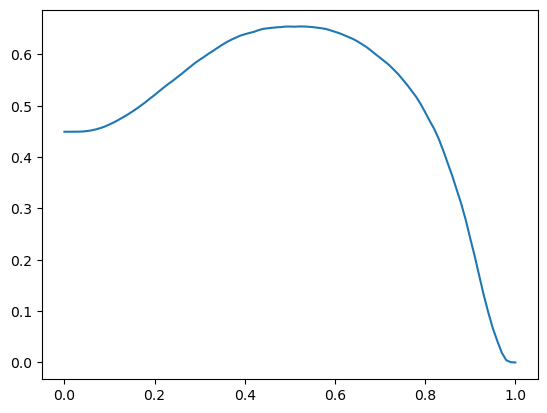

In [21]:
from sklearn.metrics import f1_score

f1 = []

thresholds = np.linspace(0, 1, 101)

for thresh in thresholds:
    y_pred = (lr_smt.predict_proba(X_train_std)[:, 1] > thresh)
    f1.append(f1_score(y_train, y_pred))

sns.lineplot(x=thresholds, y=f1)

In [22]:
thresh = thresholds[f1.index(max(f1))]

thresh

0.52

In [23]:
preds = lr_smt.predict_proba(X_test_std)[:, 1] > thresh

print(f"Accuracy: {accuracy_score(y_test, preds)}")
print(f"Precision: {precision_score(y_test, preds)}")
print(f"Recall: {recall_score(y_test, preds)}")
print(f"F1: {f1_score(y_test, preds)}")

Accuracy: 0.7859
Precision: 0.615315179780352
Recall: 0.70335339638865
F1: 0.6563954421441182


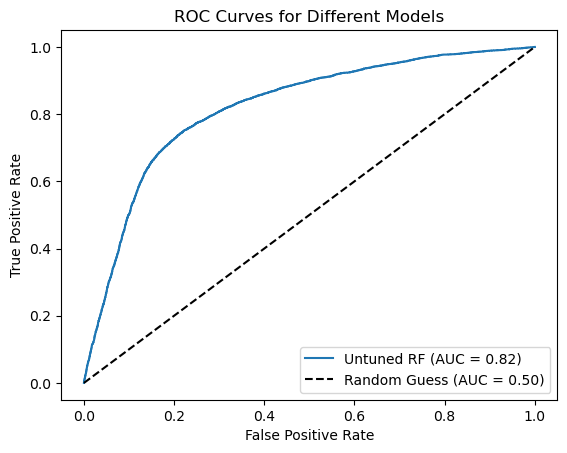

In [24]:
# Generate ROC AUC for smote model
y_probs = lr_smt.predict_proba(X_test_std)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = auc(fpr, tpr)

# Plot the ROC curve
plt.plot(fpr, tpr, label=f'Untuned RF (AUC = {auc_score:.2f})')

# Draw Random Guess
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')

# Modify Formatting
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Different Models')
plt.legend()
plt.show()